In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import shap

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from pylab import rcParams

/opt/anaconda3/envs/AI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline

In [3]:
rcParams['figure.figsize'] = 10, 6
rcParams['lines.linewidth'] = 2
rcParams['lines.markersize'] = 6
rcParams['font.size'] = 12
rcParams["font.family"] = "Times New Roman"

In [4]:
# Set display options to show the full result
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [5]:
# Load the DataFrame from the pickle file
pickle_file_path = "project_folder/Wind/Outputs/IEA15MW.pkl"
df = pd.read_pickle(pickle_file_path)

df.head()

,Time_[s],Wind1VelX_[m/s],Wind1VelY_[m/s],Wind1VelZ_[m/s],Azimuth_[deg],BldPitch1_[deg],BldPitch2_[deg],BldPitch3_[deg],GenSpeed_[rpm],LSSTipMya_[kN-m],LSSTipMys_[kN-m],LSSTipMza_[kN-m],LSSTipMzs_[kN-m],LSShftFxa_[kN],LSShftFxs_[kN],LSShftFya_[kN],LSShftFys_[kN],LSShftFza_[kN],LSShftFzs_[kN],NacYaw_[deg],NcIMURAys_[deg/s^2],NcIMUTAxs_[m/s^2],NcIMUTAzs_[m/s^2],PtfmHeave_[m],PtfmPitch_[deg],PtfmRoll_[deg],PtfmSurge_[m],PtfmSway_[m],PtfmYaw_[deg],RootFxb1_[kN],RootFxb2_[kN],RootFxb3_[kN],RootFxc1_[kN],RootFxc2_[kN],RootFxc3_[kN],RootFyb1_[kN],RootFyb2_[kN],RootFyb3_[kN],RootFyc1_[kN],RootFyc2_[kN],RootFyc3_[kN],RootFzb1_[kN],RootFzb2_[kN],RootFzb3_[kN],RootFzc1_[kN],RootFzc2_[kN],RootFzc3_[kN],RootMxb1_[kN-m],RootMxb2_[kN-m],RootMxb3_[kN-m],RootMxc1_[kN-m],RootMxc2_[kN-m],RootMxc3_[kN-m],RootMyb1_[kN-m],RootMyb2_[kN-m],RootMyb3_[kN-m],RootMyc1_[kN-m],RootMyc2_[kN-m],RootMyc3_[kN-m],RootMzb1_[kN-m],RootMzb2_[kN-m],RootMzb3_[kN-m],RootMzc1_[kN-m],RootMzc2_[kN-m],RootMzc3_[kN-m],RotSpeed_[rpm],RotThrust_[kN],RotTorq_[kN-m],Spn1FLzb1_[kN],Spn1FLzb2_[kN],Spn1FLzb3_[kN],Spn1MLxb1_[kN-m],Spn1MLxb2_[kN-m],Spn1MLxb3_[kN-m],Spn1MLyb1_[kN-m],Spn1MLyb2_[kN-m],Spn1MLyb3_[kN-m],Spn2FLzb1_[kN],Spn2FLzb2_[kN],Spn2FLzb3_[kN],Spn2MLxb1_[kN-m],Spn2MLxb2_[kN-m],Spn2MLxb3_[kN-m],Spn2MLyb1_[kN-m],Spn2MLyb2_[kN-m],Spn2MLyb3_[kN-m],Spn3FLzb1_[kN],Spn3FLzb2_[kN],Spn3FLzb3_[kN],Spn3MLxb1_[kN-m],Spn3MLxb2_[kN-m],Spn3MLxb3_[kN-m],Spn3MLyb1_[kN-m],Spn3MLyb2_[kN-m],Spn3MLyb3_[kN-m],Spn4FLzb1_[kN],Spn4FLzb2_[kN],Spn4FLzb3_[kN],Spn4MLxb1_[kN-m],Spn4MLxb2_[kN-m],Spn4MLxb3_[kN-m],Spn4MLyb1_[kN-m],Spn4MLyb2_[kN-m],Spn4MLyb3_[kN-m],Spn5FLzb1_[kN],Spn5FLzb2_[kN],Spn5FLzb3_[kN],Spn5MLxb1_[kN-m],Spn5MLxb2_[kN-m],Spn5MLxb3_[kN-m],Spn5MLyb1_[kN-m],Spn5MLyb2_[kN-m],Spn5MLyb3_[kN-m],Spn6FLzb1_[kN],Spn6FLzb2_[kN],Spn6FLzb3_[kN],Spn6MLxb1_[kN-m],Spn6MLxb2_[kN-m],Spn6MLxb3_[kN-m],Spn6MLyb1_[kN-m],Spn6MLyb2_[kN-m],Spn6MLyb3_[kN-m],Spn7FLzb1_[kN],Spn7FLzb2_[kN],Spn7FLzb3_[kN],Spn7MLxb1_[kN-m],Spn7MLxb2_[kN-m],Spn7MLxb3_[kN-m],Spn7MLyb1_[kN-m],Spn7MLyb2_[kN-m],Spn7MLyb3_[kN-m],Spn8FLzb1_[kN],Spn8FLzb2_[kN],Spn8FLzb3_[kN],Spn8MLxb1_[kN-m],Spn8MLxb2_[kN-m],Spn8MLxb3_[kN-m],Spn8MLyb1_[kN-m],Spn8MLyb2_[kN-m],Spn8MLyb3_[kN-m],Spn9FLzb1_[kN],Spn9FLzb2_[kN],Spn9FLzb3_[kN],Spn9MLxb1_[kN-m],Spn9MLxb2_[kN-m],Spn9MLxb3_[kN-m],Spn9MLyb1_[kN-m],Spn9MLyb2_[kN-m],Spn9MLyb3_[kN-m],TipDxb1_[m],TipDxb2_[m],TipDxb3_[m],TipDxc1_[m],TipDxc2_[m],TipDxc3_[m],TipDyb1_[m],TipDyb2_[m],TipDyb3_[m],TipDyc1_[m],TipDyc2_[m],TipDyc3_[m],TipDzb1_[m],TipDzb2_[m],TipDzb3_[m],TipDzc1_[m],TipDzc2_[m],TipDzc3_[m],TwHt1FLxt_[kN],TwHt1FLyt_[kN],TwHt1FLzt_[kN],TwHt1MLxt_[kN-m],TwHt1MLyt_[kN-m],TwHt1MLzt_[kN-m],TwHt2FLxt_[kN],TwHt2FLyt_[kN],TwHt2FLzt_[kN],TwHt2MLxt_[kN-m],TwHt2MLyt_[kN-m],TwHt2MLzt_[kN-m],TwHt3FLxt_[kN],TwHt3FLyt_[kN],TwHt3FLzt_[kN],TwHt3MLxt_[kN-m],TwHt3MLyt_[kN-m],TwHt3MLzt_[kN-m],TwHt4FLxt_[kN],TwHt4FLyt_[kN],TwHt4FLzt_[kN],TwHt4MLxt_[kN-m],TwHt4MLyt_[kN-m],TwHt4MLzt_[kN-m],TwHt5FLxt_[kN],TwHt5FLyt_[kN],TwHt5FLzt_[kN],TwHt5MLxt_[kN-m],TwHt5MLyt_[kN-m],TwHt5MLzt_[kN-m],TwHt6FLxt_[kN],TwHt6FLyt_[kN],TwHt6FLzt_[kN],TwHt6MLxt_[kN-m],TwHt6MLyt_[kN-m],TwHt6MLzt_[kN-m],TwHt7FLxt_[kN],TwHt7FLyt_[kN],TwHt7FLzt_[kN],TwHt7MLxt_[kN-m],TwHt7MLyt_[kN-m],TwHt7MLzt_[kN-m],TwHt8FLxt_[kN],TwHt8FLyt_[kN],TwHt8FLzt_[kN],TwHt8MLxt_[kN-m],TwHt8MLyt_[kN-m],TwHt8MLzt_[kN-m],TwHt9FLxt_[kN],TwHt9FLyt_[kN],TwHt9FLzt_[kN],TwHt9MLxt_[kN-m],TwHt9MLyt_[kN-m],TwHt9MLzt_[kN-m],TwrBsFxt_[kN],TwrBsFyt_[kN],TwrBsFzt_[kN],TwrBsMxt_[kN-m],TwrBsMyt_[kN-m],TwrBsMzt_[kN-m],YawBrFxp_[kN],YawBrFyp_[kN],YawBrFzp_[kN],YawBrMxp_[kN-m],YawBrMyp_[kN-m],YawBrMzp_[kN-m],B1N1Alpha_[deg],B1N2Alpha_[deg],B1N3Alpha_[deg],B1N4Alpha_[deg],B1N5Alpha_[deg],B1N6Alpha_[deg],B1N7Alpha_[deg],B1N8Alpha_[deg],B1N9Alpha_[deg],B2N1Alpha_[deg],B2N2Alpha_[deg],B2N3Alpha_[deg],B2N4Alpha_[deg],B2N5Alpha_[deg],B2N6Alpha_[deg],B2N7Alpha_[deg],B2N8Alpha_[deg],B2N9Alpha_[deg],B3N1Alpha_[deg],B3N2Alpha_[deg],B3N3Alpha_[deg],B3N4Alpha_[deg],B3N5Alpha_[deg],B3N6Alpha_[deg],

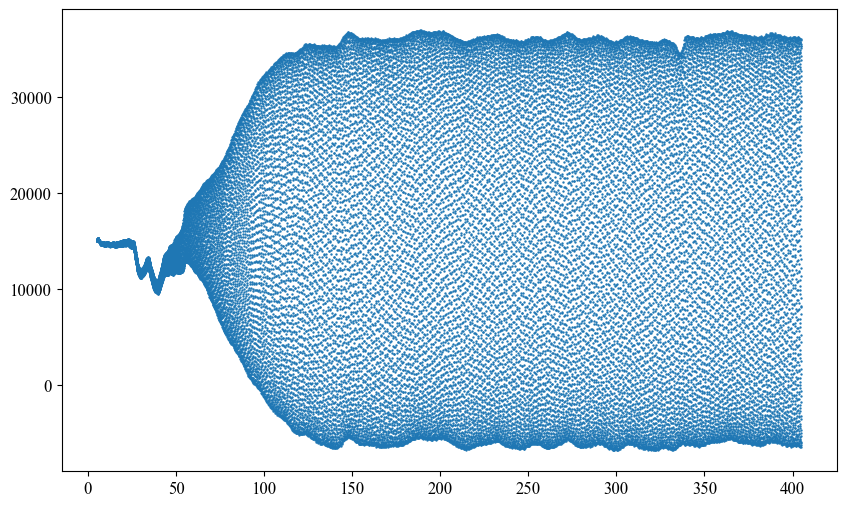

In [6]:
plt.scatter(df['Time_[s]'], df['GenPwr_[kW]'], s=0.5)

In [7]:
# Add the Rated_Pwr column
df['Rated_Pwr'] = df['GenPwr_[kW]'].apply(lambda x: 1 if x > 15000 else 0)

In [8]:
# Calculate Spearman correlation for the Rated_Pwr column
spearman_corr = df.corr(method='spearman')['Rated_Pwr'].sort_values(ascending=False)
print("\nSpearman Correlation with Rated_Pwr:")
print(spearman_corr)


Spearman Correlation with Rated_Pwr:
Rated_Pwr              1.000000
GenPwr_[kW]            0.861769
RotSpeed_[rpm]         0.860005
GenSpeed_[rpm]         0.860005
TwHt1MLxt_[kN-m]       0.716729
PtfmSway_[m]           0.468130
YawBrFxp_[kN]          0.208843
TwHt9FLxt_[kN]         0.165641
NcIMUTAzs_[m/s^2]      0.163358
NcIMUTAxs_[m/s^2]      0.162513
RtVAvgxh_[m/s]         0.158510
Time_[s]               0.152375
TwrBsMxt_[kN-m]        0.152302
GenTq_[kN-m]           0.146494
ReactMYss_[N*m]        0.134907
M3N1FKye_[N]           0.130209
BldPitch2_[deg]        0.128743
BldPitch1_[deg]        0.128743
BldPitch3_[deg]        0.128743
M5N1MKxe_[N*m]         0.125359
ReactFXss_[N]          0.125100
ReactFZss_[N]          0.118248
TwHt2MLxt_[kN-m]       0.097888
Wind1VelX_[m/s]        0.093294
ReactMXss_[N*m]        0.088911
TwrBsFxt_[kN]          0.082168
Wind1VelY_[m/s]        0.079745
M2N1FKye_[N]           0.077959
B1N2Alpha_[deg]        0.076691
TwHt1FLxt_[kN]         0.075056
M4

Accuracy: 0.9792525934258218
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      4372
           1       0.96      1.00      0.98      3629

    accuracy                           0.98      8001
   macro avg       0.98      0.98      0.98      8001
weighted avg       0.98      0.98      0.98      8001



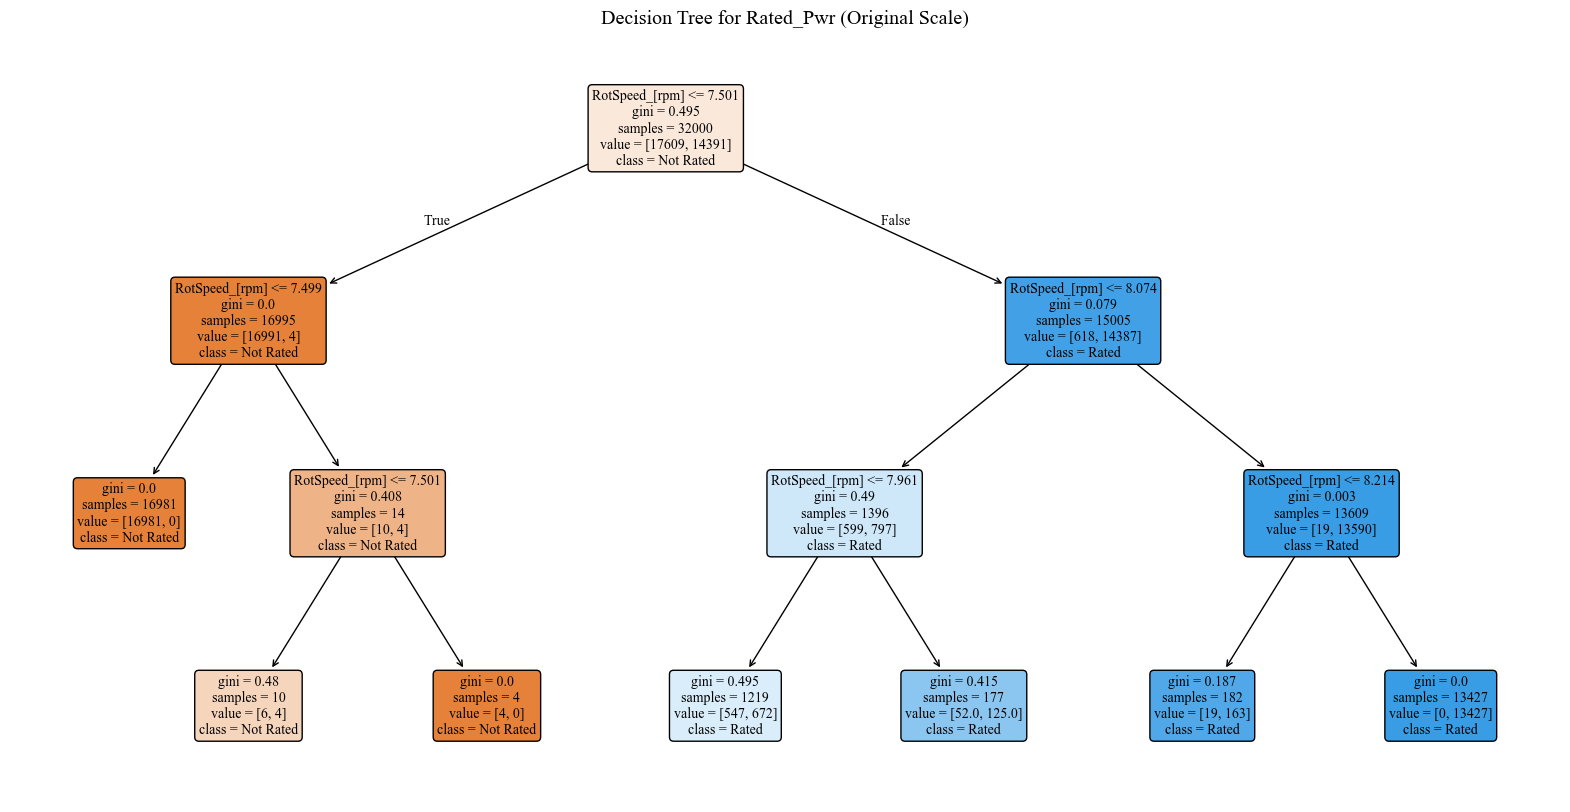

Decision Tree Rules for Rated_Pwr (Original Scale):
|--- RotSpeed_[rpm] <= 7.50
|   |--- RotSpeed_[rpm] <= 7.50
|   |   |--- class: 0
|   |--- RotSpeed_[rpm] >  7.50
|   |   |--- RotSpeed_[rpm] <= 7.50
|   |   |   |--- class: 0
|   |   |--- RotSpeed_[rpm] >  7.50
|   |   |   |--- class: 0
|--- RotSpeed_[rpm] >  7.50
|   |--- RotSpeed_[rpm] <= 8.07
|   |   |--- RotSpeed_[rpm] <= 7.96
|   |   |   |--- class: 1
|   |   |--- RotSpeed_[rpm] >  7.96
|   |   |   |--- class: 1
|   |--- RotSpeed_[rpm] >  8.07
|   |   |--- RotSpeed_[rpm] <= 8.21
|   |   |   |--- class: 1
|   |   |--- RotSpeed_[rpm] >  8.21
|   |   |   |--- class: 1


Feature Importance:
RotSpeed_[rpm]    1.0
dtype: float64


In [9]:
# Select relevant columns
# input_features = ['GenSpeed_[rpm]', 'RotSpeed_[rpm]', 'TwHt1MLxt_[kN-m]']
input_features = ['RotSpeed_[rpm]']

target_variable = 'Rated_Pwr'

# Extract input variables (X) and output variable (y)
X = df[input_features]
y = df[target_variable]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the input data
scaler_X = StandardScaler()
X_train_normalized = scaler_X.fit_transform(X_train)
X_test_normalized = scaler_X.transform(X_test)

# Train a Decision Tree model
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_normalized, y_train)

# Make predictions on the testing set
y_pred = tree_model.predict(X_test_normalized)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))

# Inverse transform the normalized data to original scale
X_train_original = scaler_X.inverse_transform(X_train_normalized)
X_test_original = scaler_X.inverse_transform(X_test_normalized)

# Train a Decision Tree model on the original scale data
tree_model_original = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model_original.fit(X_train_original, y_train)

# Visualize the decision tree with original values
plt.figure(figsize=(20, 10))
plot_tree(tree_model_original, feature_names=input_features, class_names=['Not Rated', 'Rated'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Rated_Pwr (Original Scale)")
plt.show()

# Extract rules from the decision tree with original values
tree_rules_original = export_text(tree_model_original, feature_names=input_features)
print(f"Decision Tree Rules for Rated_Pwr (Original Scale):\n{tree_rules_original}\n")

# Feature importance
feature_importance = pd.Series(tree_model_original.feature_importances_, index=input_features).sort_values(ascending=False)
print("Feature Importance:")
print(feature_importance)

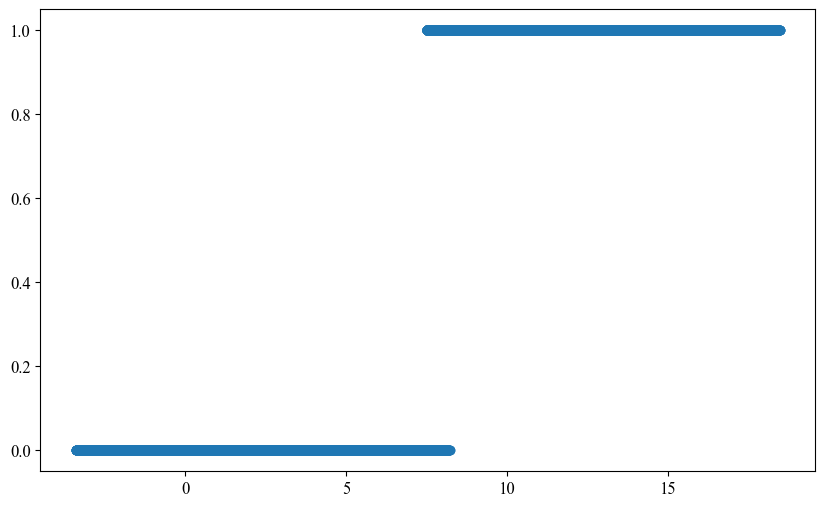

In [10]:
plt.scatter(df['RotSpeed_[rpm]'], df['Rated_Pwr'])